Some particles are outside the radius of 1.


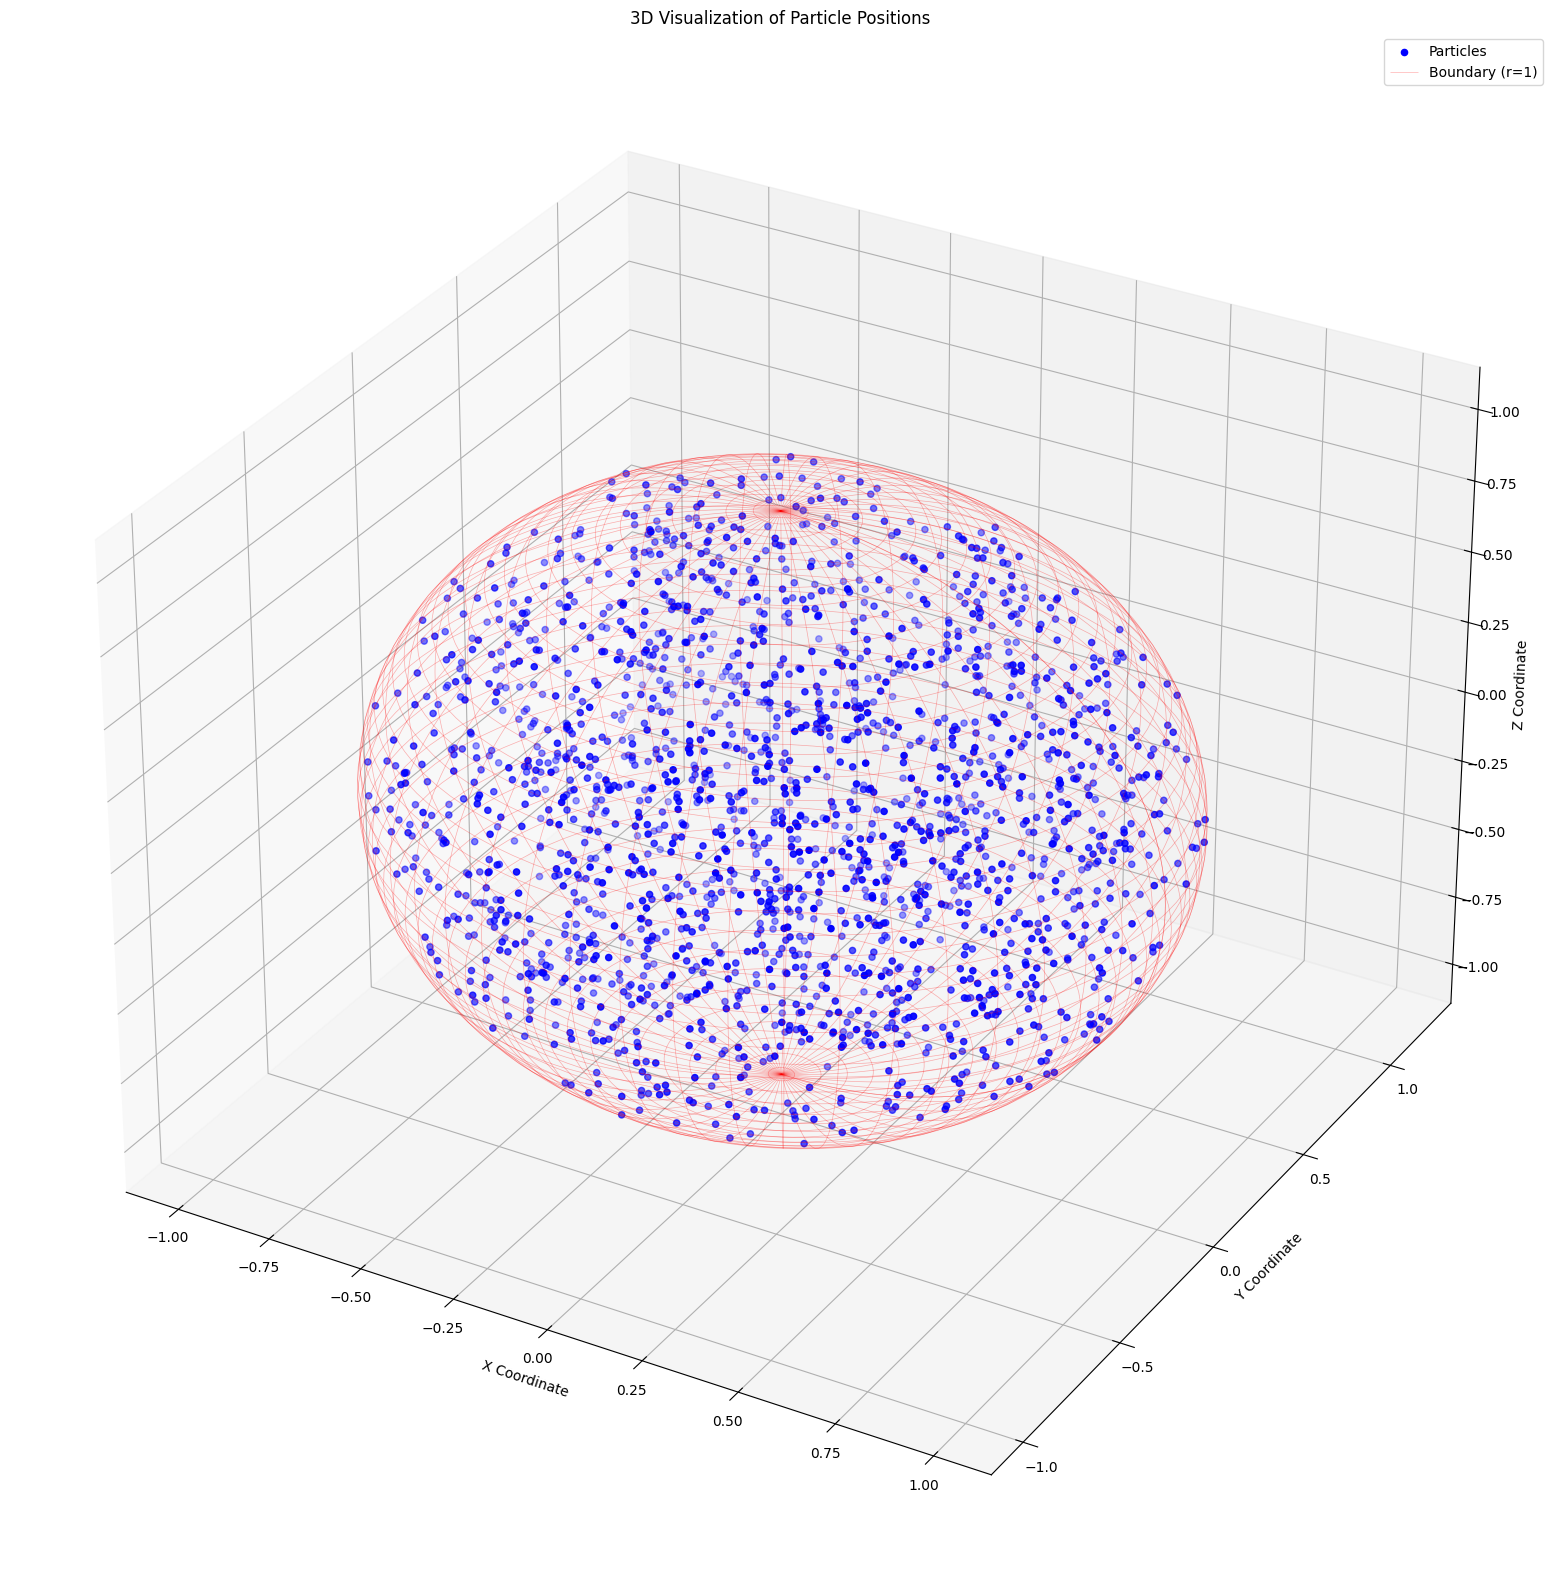

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Step 1: Load the data
data = np.loadtxt('initial_position.dat')
x = data[:, 0]
y = data[:, 1]
z = data[:, 2]

# Step 2: Check if particles are within the radius
distances = np.sqrt(x**2 + y**2 + z**2)
if np.all(distances <= 1):
    print("All particles are within the radius of 1.")
else:
    print("Some particles are outside the radius of 1.")

# Step 3: Create a 3D scatter plot
fig = plt.figure(figsize=(20,20))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z, c='b', marker='o', label='Particles')

# Step 4: Create a sphere outline
# Define the spherical coordinates
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
x_sphere = np.outer(np.cos(u), np.sin(v))
y_sphere = np.outer(np.sin(u), np.sin(v))
z_sphere = np.outer(np.ones(np.size(u)), np.cos(v))

# Plot the spherical surface with a wireframe
ax.plot_wireframe(x_sphere, y_sphere, z_sphere, color='r', alpha=0.3, linewidth=0.5, label='Boundary (r=1)')

# Labeling axes
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_zlabel('Z Coordinate')
ax.set_title('3D Visualization of Particle Positions')
ax.legend()

# Show the plot
plt.show()


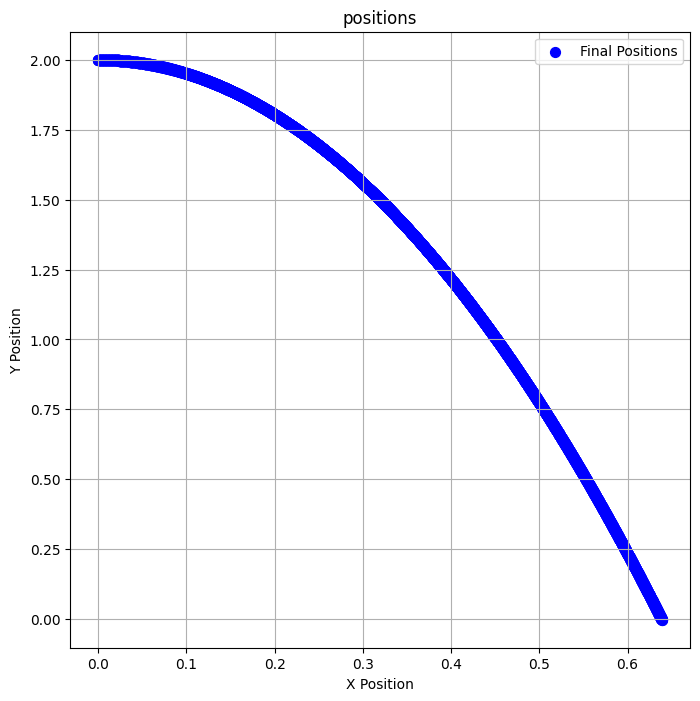

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Load the position data
positions = np.loadtxt('2D_evolution_r.dat')  # Each row: [x1, y1, x2, y2, ...]
x = positions[:,0]
y = positions[:,1]

plt.figure(figsize=(8, 8))
plt.scatter(x, y, c='blue', s=50, label='Final Positions')

plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title('positions')
plt.legend()
plt.grid(True)
plt.show()


100


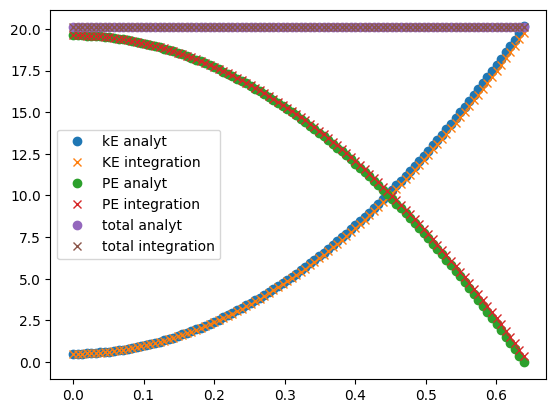

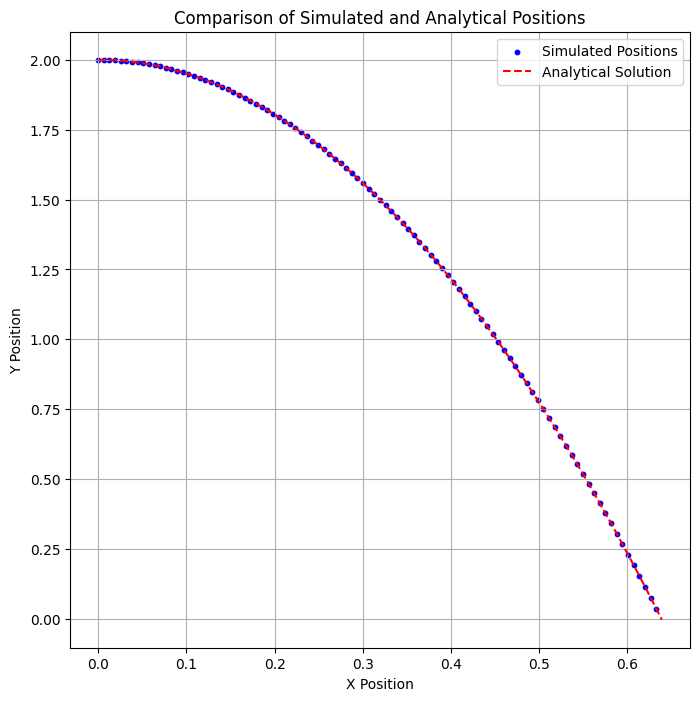

In [56]:
import numpy as np
import matplotlib.pyplot as plt

# Given constants
v0 = 1.0       # initial velocity in x-direction
g = 9.81     # gravitational acceleration
total_time = 0.639  # total simulation time
num_steps = 100    # number of time steps
dt = total_time / num_steps  # time step size

# Generate time array for analytical solution
time_steps = np.linspace(0, total_time, num_steps)

# Analytical solution
x_analytical = v0 * time_steps
y_analytical = -0.5 * g * time_steps**2 + 2
vx_analyt = np.array([v0]*len(time_steps))
vy_analyt = -1*g*time_steps
print(len(vx_analyt))
KE_analyt = 0.5*(vx_analyt**2+vy_analyt**2)
PE_analyt = 9.81*y_analytical

# Step 1: Load the simulated position data
positions = np.loadtxt('2D_evolution_r.dat')  # Each row: [x1, y1, x2, y2, ...]
x_sim = positions[:, 0]
y_sim = positions[:, 1]

# Step 1: Load the simulated position data
velocities = np.loadtxt('2D_evolution_v.dat')  # Each row: [x1, y1, x2, y2, ...]
vx_sim = velocities[:, 0]
vy_sim = velocities[:, 1]

KE_sim = 0.5*(vx_sim**2 + vy_sim**2)
PE_sim = 9.81*y_sim
plt.figure()
plt.plot(time_steps, KE_analyt, 'o', label='kE analyt')
plt.plot(time_steps, KE_sim, 'x', label='KE integration')


plt.plot(time_steps, PE_analyt, 'o', label='PE analyt')
plt.plot(time_steps, PE_sim, 'x', label='PE integration')

plt.plot(time_steps, KE_analyt+PE_analyt, 'o', label='total analyt')
plt.plot(time_steps, KE_sim+PE_sim, 'x', label='total integration')



plt.legend()
# Plotting
plt.figure(figsize=(8, 8))

# Plot simulated positions
plt.scatter(x_sim, y_sim, c='blue', s=10, label='Simulated Positions')

# Plot analytical positions
plt.plot(x_analytical, y_analytical, 'r--', label='Analytical Solution')

# Add labels and legend
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title('Comparison of Simulated and Analytical Positions')
plt.legend()
plt.grid(True)
plt.show()


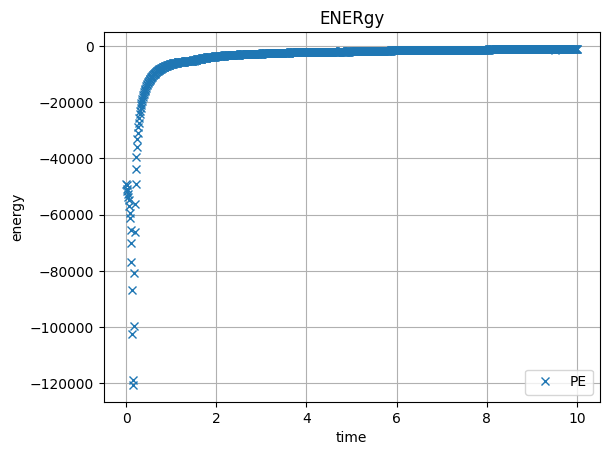

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Load the simulated position data
KE = np.loadtxt('KE.dat')  # Each row: [x1, y1, x2, y2, ...]


# Step 1: Load the simulated position data
PE = np.loadtxt('PE.dat')  # Each row: [x1, y1, x2, y2, ...]

total_time = 10.  # total simulation time
num_steps = 1000    # number of time steps
dt = total_time / num_steps  # time step size

# Generate time array for analytical solution
time_steps = np.linspace(0, total_time, num_steps)

plt.figure()
#plt.plot(time_steps, KE, 'o', label='kE')
plt.plot(time_steps, PE, 'x', label='PE')
#plt.plot(time_steps, KE+PE, 'x', label='total')



# Add labels and legend
plt.xlabel('time')
plt.ylabel('energy')
plt.title('ENERgy')
plt.legend()
plt.grid(True)
plt.show()
